Импортируем необходимые библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import phik
from phik.report import plot_correlation_matrix

from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from lightgbm import LGBMRegressor

pd.set_option('display.max_columns', None)

### Изучение общей информации о данных

Прочитаем файл с данными и изучим общую информацию о данных

In [2]:
dt = pd.read_csv('./data/data_final.csv')
display(dt.info())
display(dt.head())

<class 'pandas.DataFrame'>
RangeIndex: 142285 entries, 0 to 142284
Data columns (total 59 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   first_seen            142285 non-null  str    
 1   days_on_market        142285 non-null  int64  
 2   event_closed          142285 non-null  int64  
 3   mortgage_allowed      142285 non-null  int64  
 4   deal_conditions       142285 non-null  str    
 5   region                142285 non-null  str    
 6   municipality          142285 non-null  str    
 7   district              142285 non-null  str    
 8   lat                   142285 non-null  float64
 9   lon                   142285 non-null  float64
 10  n_metro               142285 non-null  int64  
 11  nearest_metro         142285 non-null  str    
 12  nearest_metro_time    142285 non-null  float64
 13  nearest_metro_walk    142285 non-null  int64  
 14  rooms                 142285 non-null  float64
 15  is_studio  

None

,first_seen,days_on_market,event_closed,mortgage_allowed,deal_conditions,region,municipality,district,lat,lon,n_metro,nearest_metro,nearest_metro_time,nearest_metro_walk,rooms,is_studio,flat_type,total_area,living_area,kitchen_area,floor,total_floors,ceiling_height,renovation,window_view,is_apartments,building_type,parking,is_new_building,seller_type,phone_protected,views_total,price_first,price_last,price_points,dist_to_center,price_per_m2,building_age,is_ready,completion_year,years_to_completion,is_presale,has_completion,had_discount,price_drop_pct,is_first_floor,is_last_floor,floor_ratio,living_to_total,kitchen_to_total,area_per_room,ppm2_to_district,ppm2_to_municipality,total_lifts,has_lift,bath_separate,bath_combined,balcony_count,loggia_count
0,2026-04-07 00:17:49.545645+00:00,3801,1,0,alternative,Москва,САО,Беговой,55.781467,37.561070,3,Беговая,13.0,0,3.0,0,unknown,73.8,45.3,8.8,3,14,2.80,cosmetic,yardAndStreet,0,brick,unknown,0,specialist,0,NaN,26000000,26000000,1,4.816265,352303.523035,56,True,NaN,NaN,0,0,0,0.000000,0,0,0.214286,0.613821,0.119241,24.600000,0.660886,0.898802,0.0,0,1,0,0,2
1,2026-04-06 21:40:26.848342+00:00,3766,1,0,alternative,Московская область,Реутов,unknown,55.763790,37.858013,3,Новогиреево,13.0,0,3.0,0,unknown,90.1,64.0,9.1,4,4,2.65,cosmetic,unknown,0,unknown,unknown,0,agency,0,NaN,16490000,16490000,1,15.105500,183018.867925,64,True,NaN,NaN,0,0,0,0.000000,0,1,1.000000,0.710322,0.100999,30.033333,0.855915,0.762837,0.0,0,1,0,2,0
2,2026-04-07 00:14:06.924608+00:00,3520,1,1,free,Москва,Красная Пахра село,unknown,55.431595,37.271490,3,Потапово,24.0,0,3.0,0,rooms,92.0,52.0,15.0,4,6,3.00,euro,yardAndStreet,0,brick,ground,0,specialist,1,167.0,22000000,22000000,1,41.737163,239130.434783,19,True,NaN,NaN,0,0,0,0.000000,0,0,0.666667,0.565217,0.163043,30.666667,1.118329,0.993272,0.0,0,1,1,0,1
3,2026-04-10 15:36:16.683205+00:00,3554,1,1,free,Московская область,Красногорск,unknown,55.813618,37.311794,3,Красногорская,8.0,1,2.0,0,rooms,48.0,36.0,7.5,2,5,2.80,euro,unknown,0,panel,ground,0,specialist,1,1476.0,10500000,10500000,1,20.306127,218750.000000,56,True,NaN,NaN,0,0,0,0.000000,0,0,0.400000,0.750000,0.156250,24.000000,0.970067,0.810226,0.0,0,0,1,1,0
4,2026-04-06 23:59:38.314351+00:00,3434,1,1,free,Московская область,Истра муниципальный округ,unknown,55.863490,37.045868,1,Нахабино,20.0,0,1.0,0,rooms,43.9,12.0,13.0,9,15,2.80,cosmetic,unknown,0,monolith,ground,0,specialist,1,1623.0,6700000,6950000,3,37.810351,152619.589977,13,True,NaN,NaN,0,0,0,-0.037313,0,0,0.600000,0.273349,0.296128,43.900000,0.615714,0.760341,2.0,1,0,1,0,1


Видим, что не у всех данных корректный тип данных, поэтому приведем столбцы датафрейма к корректным типам. first_seen нужно сделать датой, количественные показатели числом, а бинарные сделать типом bool.

In [3]:
dt['first_seen'] = pd.to_datetime(dt['first_seen'],format='ISO8601')
dt[['rooms','total_lifts','views_total']] = dt[['rooms','total_lifts','views_total']].astype('Int64')
dt[['event_closed','mortgage_allowed','nearest_metro_walk','is_studio','is_apartments','is_new_building',
    'phone_protected','had_discount','is_first_floor','is_last_floor','has_lift']] = dt[['event_closed','mortgage_allowed',
                                                                                         'nearest_metro_walk','is_studio','is_apartments','is_new_building',
                                                                                         'phone_protected','had_discount','is_first_floor','is_last_floor','has_lift']].astype('bool')

Посмотрим на данные еще раз, чтобы убедиться, что типы данных теперь корректные и соответствуют по смыслу.

In [4]:
dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 142285 entries, 0 to 142284
Data columns (total 59 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   first_seen            142285 non-null  datetime64[us, UTC]
 1   days_on_market        142285 non-null  int64              
 2   event_closed          142285 non-null  bool               
 3   mortgage_allowed      142285 non-null  bool               
 4   deal_conditions       142285 non-null  str                
 5   region                142285 non-null  str                
 6   municipality          142285 non-null  str                
 7   district              142285 non-null  str                
 8   lat                   142285 non-null  float64            
 9   lon                   142285 non-null  float64            
 10  n_metro               142285 non-null  int64              
 11  nearest_metro         142285 non-null  str                
 12 

Посмотрим на количество пропусков

In [5]:
dt.isna().sum().sort_values(ascending = False)

completion_year         63336
years_to_completion     63336
views_total              4483
mortgage_allowed            0
deal_conditions             0
region                      0
municipality                0
district                    0
first_seen                  0
days_on_market              0
event_closed                0
nearest_metro               0
nearest_metro_time          0
nearest_metro_walk          0
rooms                       0
is_studio                   0
flat_type                   0
total_area                  0
living_area                 0
kitchen_area                0
floor                       0
total_floors                0
ceiling_height              0
renovation                  0
lat                         0
lon                         0
n_metro                     0
building_type               0
is_apartments               0
window_view                 0
parking                     0
phone_protected             0
price_first                 0
seller_typ

Видим, что пропусков нет нигде, кроме трех полей: в views_today, photos_count и views_total.

In [6]:
(dt == 'unknown').sum().sort_values(ascending = False)

renovation              81518
district                76785
window_view             68613
parking                 62304
municipality            44938
building_type           22196
nearest_metro            7323
flat_type                  93
event_closed                0
deal_conditions             0
days_on_market              0
n_metro                     0
lon                         0
lat                         0
region                      0
mortgage_allowed            0
rooms                       0
nearest_metro_walk          0
nearest_metro_time          0
living_area                 0
total_area                  0
is_studio                   0
kitchen_area                0
ceiling_height              0
total_floors                0
floor                       0
first_seen                  0
is_apartments               0
is_new_building             0
seller_type                 0
phone_protected             0
views_total                 0
price_first                 0
price_last

Посмотрим, сколько unknown есть в данных, их значительно больше, чем пропусков, нас особенно беспокоит 95% по district

In [7]:
dt.describe()

,days_on_market,lat,lon,n_metro,nearest_metro_time,rooms,total_area,living_area,kitchen_area,floor,total_floors,ceiling_height,views_total,price_first,price_last,price_points,dist_to_center,price_per_m2,building_age,completion_year,years_to_completion,is_presale,has_completion,price_drop_pct,floor_ratio,living_to_total,kitchen_to_total,area_per_room,ppm2_to_district,ppm2_to_municipality,total_lifts,bath_separate,bath_combined,balcony_count,loggia_count
count,142285.000000,142285.000000,142285.000000,142285.000000,142285.000000,142285.0,142285.000000,142285.000000,142285.000000,142285.000000,142285.000000,142285.000000,137802.0,1.422850e+05,1.422850e+05,142285.000000,142285.000000,142285.000000,142285.000000,78949.000000,78949.000000,142285.000000,142285.000000,142285.000000,142285.000000,142285.000000,142285.000000,142285.000000,142285.000000,142285.000000,142285.0,142285.000000,142285.000000,142285.000000,142285.000000
mean,84.570271,55.729726,37.575525,3.068054,13.407738,1.887261,55.165124,28.531821,12.884055,10.512823,19.513273,2.837929,554.534673,1.974450e+07,1.988030e+07,3.530386,21.328905,353111.219020,16.094950,2026.415002,0.415002,0.314489,0.554865,-0.009441,0.554862,0.506962,0.247531,31.331165,1.041651,1.043307,2.623446,-0.004498,0.319788,-0.416376,-0.393632
std,156.205561,0.221904,0.451258,1.062059,6.156305,0.869142,19.184010,12.947132,5.100364,8.766168,12.008550,0.258565,1883.054688,1.324393e+07,1.336783e+07,5.201602,30.745718,166661.129755,19.249487,2.316769,2.316769,0.464313,0.496982,0.083427,0.286438,0.116124,0.098669,7.984703,0.305701,0.294253,3.881594,0.793965,1.007263,0.838252,0.867900
min,0.000000,44.483532,29.961061,0.000000,1.000000,0.0,24.300000,9.200000,4.000000,-2.000000,1.000000,2.000000,1.0,4.903080e+06,4.400000e+06,1.000000,0.429728,103658.536585,-3.000000,2002.000000,-24.000000,0.000000,0.000000,-9.230769,-0.666667,0.095951,0.041007,0.722222,0.154446,0.170708,0.0,-1.000000,-1.000000,-1.000000,-1.000000
25%,14.000000,55.627590,37.428380,3.000000,9.000000,1.0,39.400000,18.000000,9.200000,4.000000,12.000000,2.700000,19.0,1.080000e+07,1.090000e+07,1.000000,11.636802,224432.011479,6.000000,2026.000000,0.000000,0.000000,0.000000,-0.008696,0.302326,0.422156,0.172786,25.360000,0.842872,0.856970,0.0,-1.000000,-1.000000,-1.000000,-1.000000
50%,36.000000,55.720420,37.549183,3.000000,13.000000,2.0,51.890000,27.100000,12.000000,8.000000,17.000000,2.800000,136.0,1.626338e+07,1.640090e+07,2.000000,19.339583,321800.000000,7.000000,2027.000000,1.000000,0.000000,1.000000,0.000000,0.560000,0.512195,0.232558,30.500000,1.000000,1.000000,2.0,0.000000,1.000000,-1.000000,-1.000000
75%,93.000000,55.833282,37.737400,3.000000,18.000000,2.0,66.100000,36.400000,16.000000,15.000000,24.000000,2.950000,599.0,2.400000e+07,2.404663e+07,4.000000,25.432144,443589.743590,14.000000,2028.000000,2.000000,1.000000,1.000000,0.000000,0.800000,0.588313,0.316206,36.700000,1.181015,1.177808,3.0,1.000000,1.000000,0.000000,0.000000
max,3801.000000,60.117370,82.961240,15.000000,60.000000,36.0,137.300000,73.000000,32.900000,76.000000,95.000000,7.900000,536340.0,1.124138e+08,1.478959e+08,147.000000,2811.650174,1000000.000000,241.000000,2030.000000,4.000000,1.000000,1.000000,0.900000,1.000000,1.000000,1.000000,135.900000,4.373423,7.177481,43.0,9.000000,9.000000,4.000000,4.000000


Посмотрели какие аномалии есть в данных. Нас особенно смущает, что 
- rooms = 0 (min), так как не бывает квартир, где нет комнат
- floor = -2 (min) - отрицательное значение этажа
- ceiling_height = 0 (min), 3250 (max) - не бывает потолков, где высота 0
- views_total = 536340 (max) - здесь нас смутило слишком большое кол-во просмотров
- dist_to_center = 2811.959345 (max) - подозрительно большое расстояние для городской недвижимости
- building_age = -3 (min), 934 (max), нереалистичный возраст здания
- floor_ratio = -0.4 (min), не имеет смысла отрицательное значение
- total_lifts = 43 (max) - так не бывает 

Посмотрим какие уникальные значения есть в каждом столбце, чтобы определить что нужно поправить, отфильтровать

In [8]:
for col in dt.select_dtypes(include = 'object').columns:
    print()
    print(col, dt[col].nunique())
    print(dt[col].value_counts().head(10))

# investment,dzhsk,свободная продажа -> alternative
# отфильтровать регионы - Москва и МО
# проверить district
# привести bathrooms?
# привести balcony?
# window_view -> на сколько сторон окна: yardAndStreet = 2, yard = 1, street = 1
# привести building_type


deal_conditions 8
deal_conditions
fz214                66384
free                 63731
alternative           9214
dupt                  2610
pdkp                   300
investment              35
dzhsk                    9
свободная продажа        2
Name: count, dtype: int64

region 6
region
Москва                   83534
Московская область       58651
Санкт-Петербург             80
Крым респ.                  12
Новосибирская область        7
Челябинская область          1
Name: count, dtype: int64

municipality 215
municipality
unknown                        44938
НАО (Новомосковский)            8545
Ленинский городской округ       6128
Мытищи                          5173
ЮВАО                            4581
Балашиха                        3936
САО                             3732
Красногорск городской округ     3703
Одинцовский городской округ     3442
ЮАО                             3439
Name: count, dtype: int64

district 175
district
unknown                 76785
Даниловский   

C:\Users\Nikita\AppData\Local\Temp\ipykernel_11556\2946004304.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in dt.select_dtypes(include = 'object').columns:


Посмотрим сколько дней объявление было показано

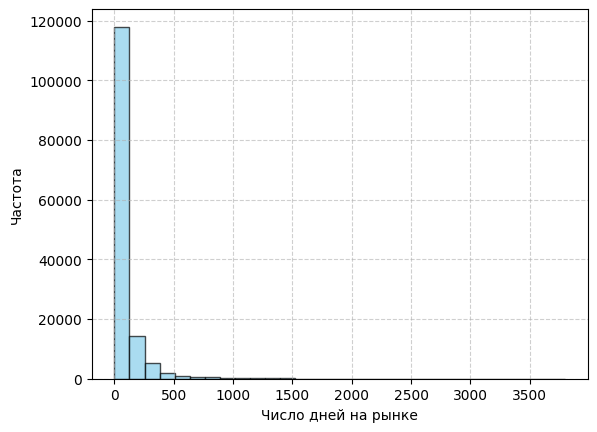

In [9]:
plt.hist(dt['days_on_market'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)

plt.xlabel('Число дней на рынке')
plt.ylabel('Частота')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

На графике видим, что большинство квартир были на рынке небольшое количество дней и быстро продавались.

In [10]:
dt = dt[dt['region'].isin(['Москва','Московская область'])]
dt.loc[dt['views_total']>100000, 'views_total'] = np.nan
dt = dt[dt['ceiling_height'].between(2, 8)]
dt = dt[dt['building_age']<300]
dom_low, dom_high = dt['days_on_market'].quantile([0.01, 0.99])
dt = dt[dt['days_on_market'].between(dom_low, dom_high)]

Очистим данные, удалим ненужные и отфильтруем аномальные значения.
- удалим views_today и photos_count - счетные признаки, более 80% пропусков, малая содержательная нагрузка + views_total
- отфильтруем только объявления в Москве и МО. Это должно также убрать выбросы по dist_to_center, lat, lon
- что касается rooms = 0 (min) - вероятно, свободная планировка, оставим пока. floor = -2 (min) - сомнительно, но окэй :)
- views_total = 536340 - такой выброс всего один, следующее максимальное значение 58733, скорее всего ошибка. Присвоим ему NaN.
- ceiling_height - возьмем от 2 метров до 8 метров (пентхаус), остальные скорее всего ошибка
- building_age = -3 (min), 934 (max) - верхнее значение точно ошибка, это Подольск, ему еще нет столько лет. А нижние (отрицательные) значения - если это в строящихся домах, то почему маркер is_ready у всех true? Надо разобраться.
- days_on_market - срезаем хвосты по 1 и 99 перцентилю (снизу мгновенные репосты, сверху "продается 10+ лет")

Посмотрим зависимости для цены за кв.м. и переменных с наибольшей корреляцией, а также зависимости для срока продажи и переменных с наибольшей корреляцией

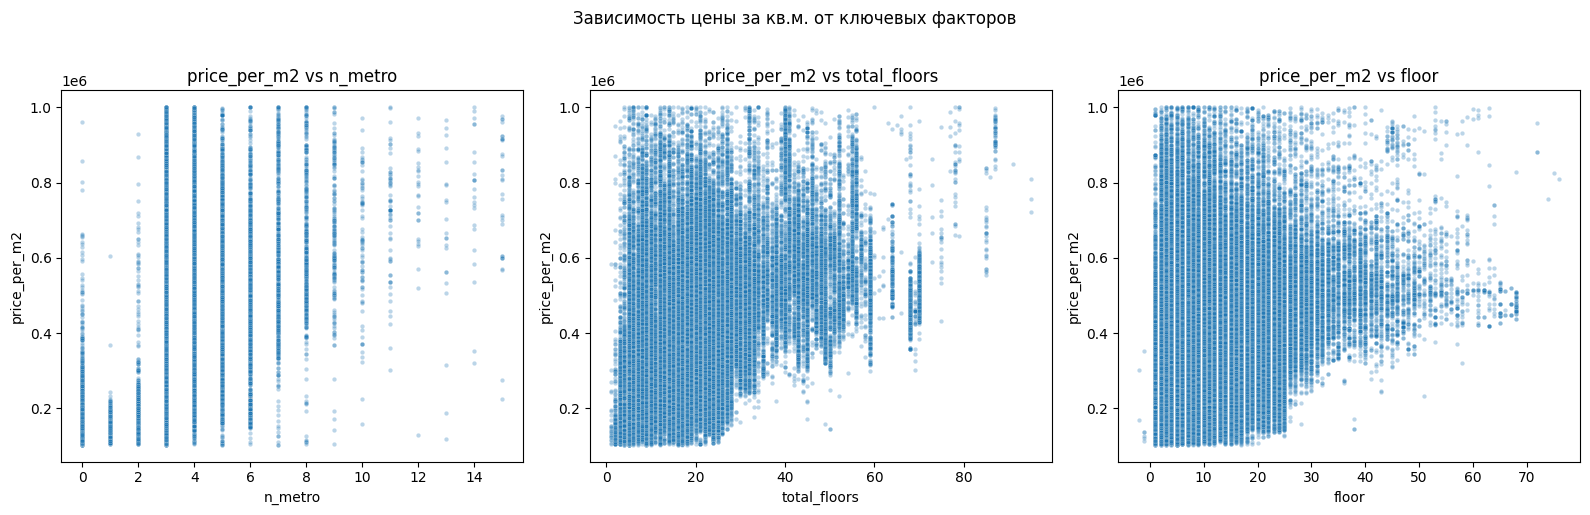

In [11]:
pairs = [
    ('n_metro', 'price_per_m2'),
    ('total_floors', 'price_per_m2'),
    ('floor', 'price_per_m2')
]

fig, axes = plt.subplots(1, len(pairs), figsize=(16, 5))

for ax, (x_col, y_col) in zip(axes, pairs):
    sns.scatterplot(data=dt, x=x_col, y=y_col, alpha=0.3, s=10, ax=ax)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{y_col} vs {x_col}')

plt.suptitle('Зависимость цены за кв.м. от ключевых факторов', y=1.02)
plt.tight_layout()
plt.show()

Видим, что цена за квадратный метр растёт с увеличением числа станций метро рядом и снижается в многоэтажных домах. Наиболее дорогие квартиры расположены на средних и низких этажах.



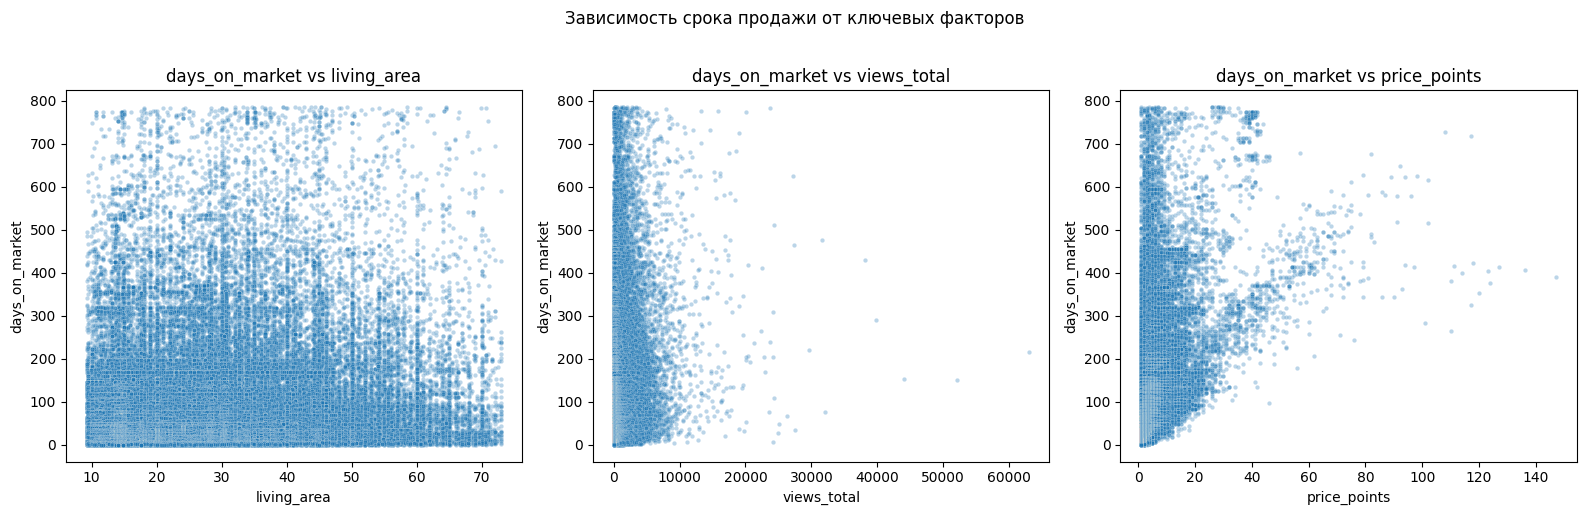

In [12]:
pairs = [
    ('living_area', 'days_on_market'),
    ('views_total', 'days_on_market'),
    ('price_points', 'days_on_market')
]

fig, axes = plt.subplots(1, len(pairs), figsize=(16, 5))

for ax, (x_col, y_col) in zip(axes, pairs):
    sns.scatterplot(data=dt, x=x_col, y=y_col, alpha=0.3, s=10, ax=ax)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{y_col} vs {x_col}')

plt.suptitle('Зависимость срока продажи от ключевых факторов', y=1.02)
plt.tight_layout()
plt.show()

Посмотрим на распределение цен за кв. метр

Срок продажи увеличивается для квартир с большой жилой площадью и низкой ценой за квадратный метр. А также видим, что чем больше просмотров, тем быстрее продается квартира.



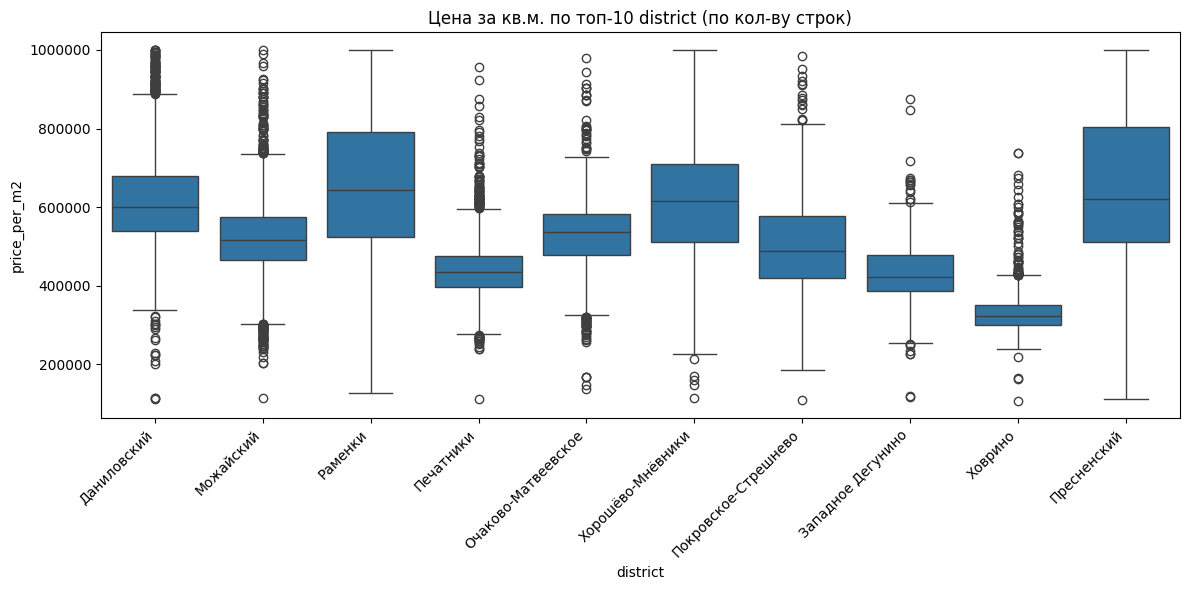

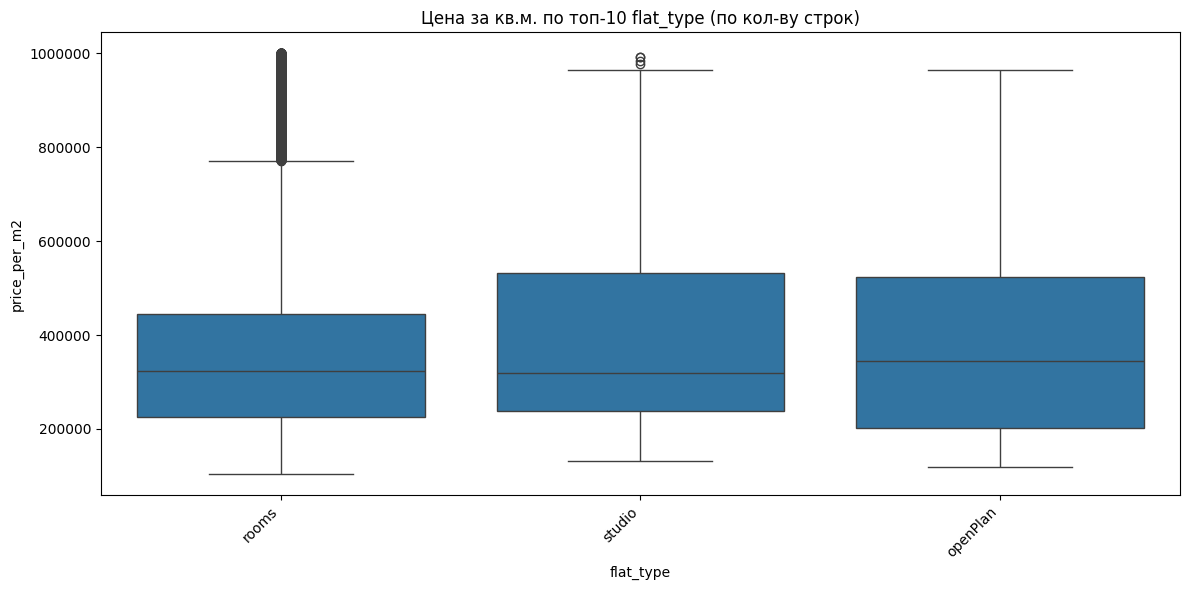

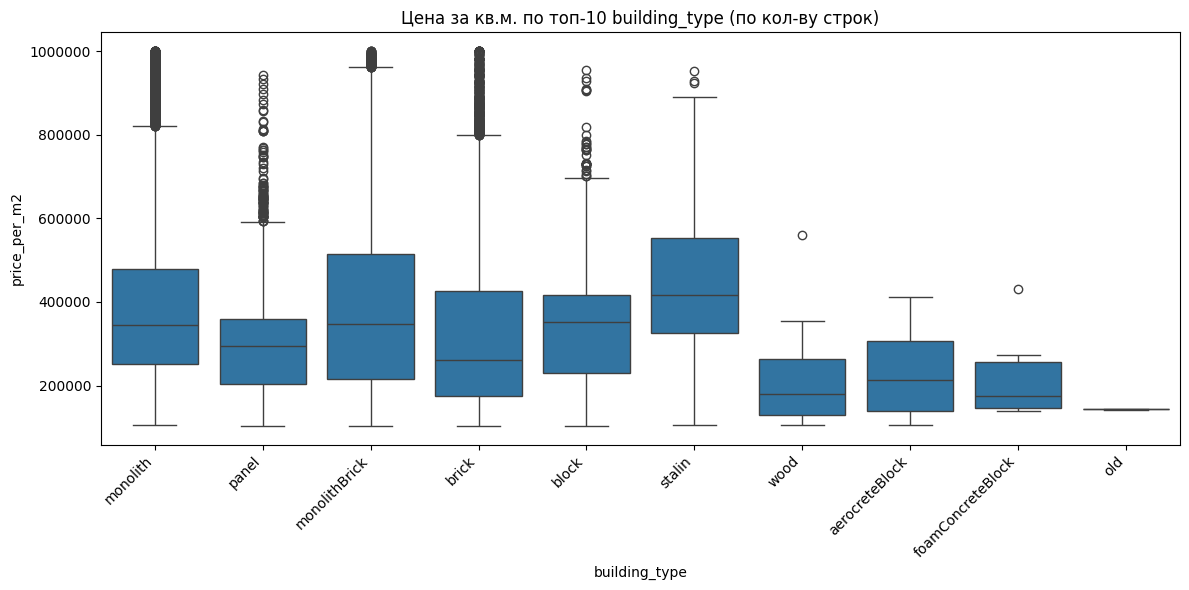

In [13]:
cols_to_plot = ['district', 'flat_type', 'building_type']

for col in cols_to_plot:
    dt_clean = dt[dt[col].ne('unknown') & dt[col].notna()]
    top_cats = dt_clean[col].value_counts().head(10).index
    dt_top = dt_clean[dt_clean[col].isin(top_cats)]
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=dt_top, x=col, y='price_per_m2', order=top_cats)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Цена за кв.м. по топ-10 {col} (по кол-ву строк)')
    plt.ticklabel_format(style='plain', axis='y')
    plt.tight_layout()
    plt.show()


Видим, что самые высокие средние цены за кв. метр в районах Раменки и Пресненский, а также в студиях и домах сталинской постройки.

### Распределение таргета (days_on_market) по категориальным признакам

In [14]:
def target_by_category(frame, col, target='days_on_market', min_count=200):
    g = frame.groupby(col)[target]
    table = g.agg(
        n='count',
        p10=lambda s: s.quantile(0.10),
        p25=lambda s: s.quantile(0.25),
        p50='median',
        p75=lambda s: s.quantile(0.75),
        p90=lambda s: s.quantile(0.90),
    )
    return table[table['n'] >= min_count].sort_values('p50').round(1)

cat_features = ['region', 'seller_type', 'rooms', 'is_new_building', 'is_apartments',
                'deal_conditions', 'building_type', 'renovation', 'parking', 'flat_type',
                'has_lift', 'mortgage_allowed', 'nearest_metro_walk']

for col in cat_features:
    print(col)
    display(target_by_category(dt, col))

region


,n,p10,p25,p50,p75,p90
region,,,,,,
Москва,82811,5.0,12.0,30.0,89.0,182.0
Московская область,57964,5.0,17.0,42.0,93.0,176.0


seller_type


,n,p10,p25,p50,p75,p90
seller_type,,,,,,
specialist,44608,6.0,16.0,29.0,71.0,150.0
agency,96065,5.0,12.0,38.0,96.0,191.0


rooms


...

,n,p10,p25,p50,p75,p90
has_lift,,,,,,
True,103536,5.0,13.0,34.0,88.0,182.0
False,37239,6.0,16.0,38.0,93.0,174.0


mortgage_allowed


,n,p10,p25,p50,p75,p90
mortgage_allowed,,,,,,
True,107914,5.0,14.0,34.0,88.0,183.0
False,32861,6.0,14.0,38.0,102.0,166.0


nearest_metro_walk


,n,p10,p25,p50,p75,p90
nearest_metro_walk,,,,,,
True,77211,5.0,13.0,31.0,89.0,182.0
False,63564,5.0,15.0,38.0,93.0,177.0


В таблицах можем увидеть распределение кол-ва дней объявления на сайте по соответствующим квантилям

Посмотрим как различные факторы влияют на скорость продажи квартиры

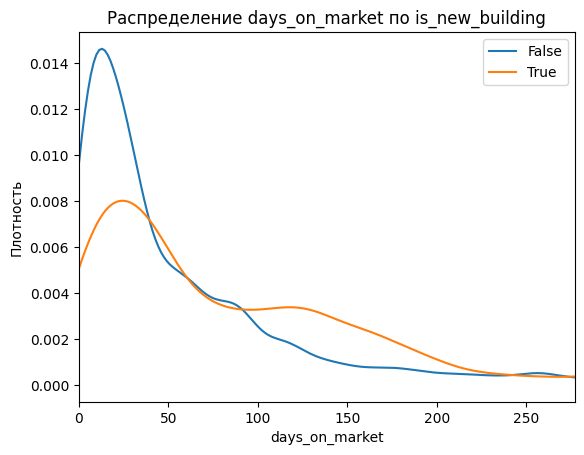

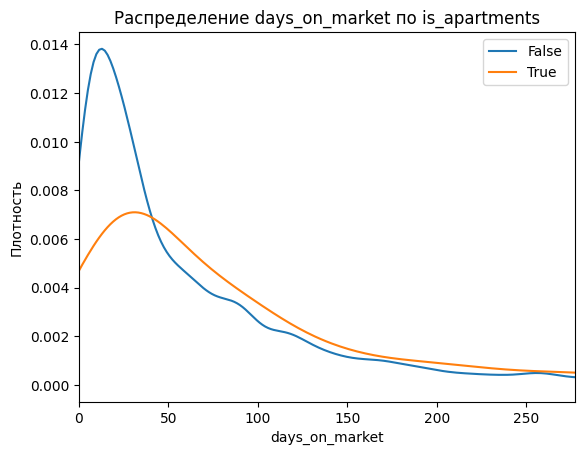

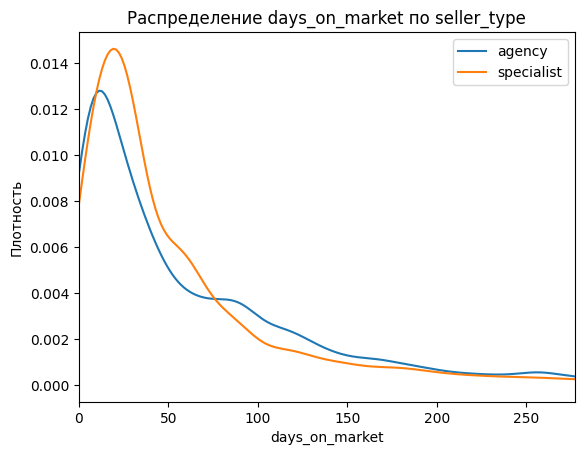

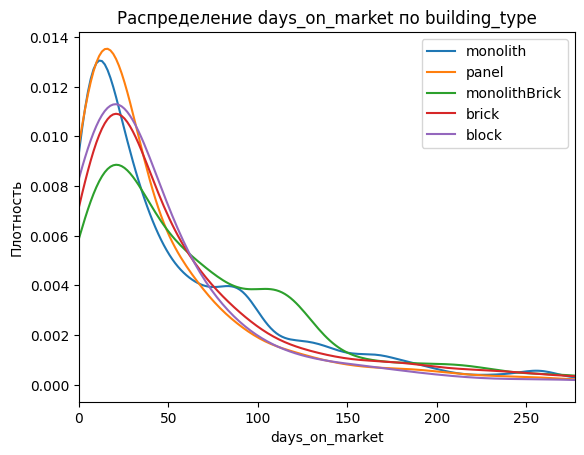

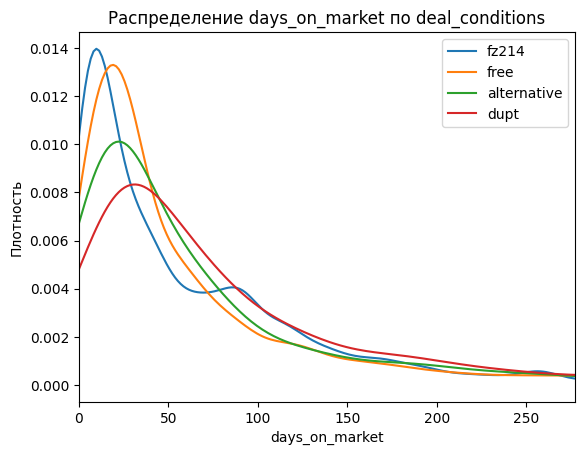

In [15]:
overlay_features = ['is_new_building', 'is_apartments', 'seller_type', 'building_type', 'deal_conditions']
clip = dt['days_on_market'].quantile(0.95)

for col in overlay_features:
    counts = dt[dt[col].ne('unknown')][col].value_counts()
    cats = counts[counts >= 500].index
    plt.figure()
    for val in cats:
        dt.loc[dt[col] == val, 'days_on_market'].plot(kind='kde', label=str(val))
    plt.title(f'Распределение days_on_market по {col}')
    plt.xlabel('days_on_market')
    plt.ylabel('Плотность')
    plt.xlim(0, clip)
    plt.legend()
    plt.show()

Посмотрим, где должна находиться квартира, чтобы ее быстрее можно было продать

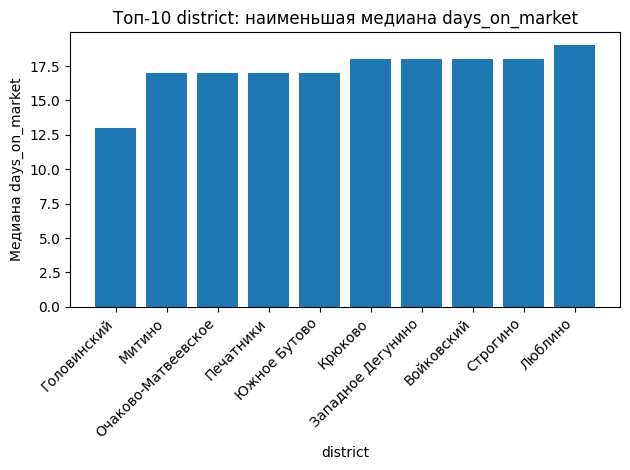

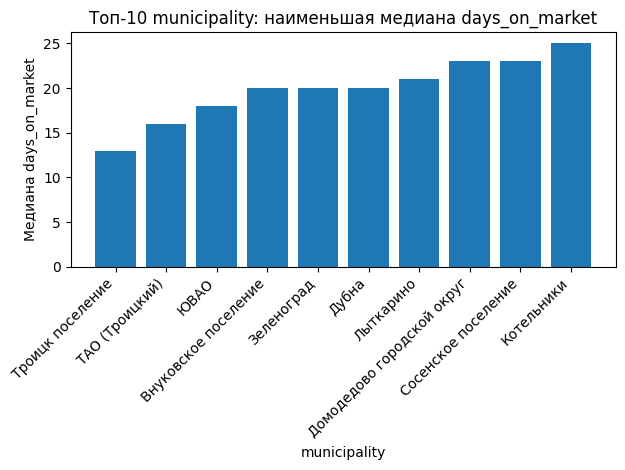

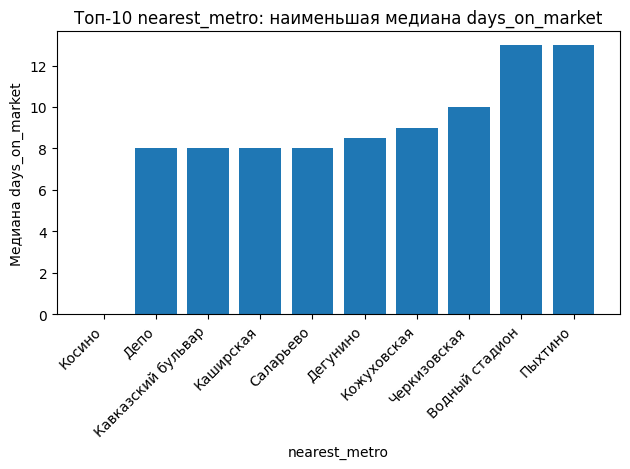

In [16]:
def lowest_median_bar(frame, col, target='days_on_market', top=10, min_count=100):
    sub = frame[frame[col].ne('unknown')]
    stats = sub.groupby(col)[target].agg(['median', 'count'])
    stats = stats[stats['count'] >= min_count].sort_values('median').head(top)
    plt.figure()
    plt.bar(stats.index, stats['median'])
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Топ-{top} {col}: наименьшая медиана days_on_market')
    plt.xlabel(col)
    plt.ylabel('Медиана days_on_market')
    plt.tight_layout()
    plt.show()

for col in ['district', 'municipality', 'nearest_metro']:
    lowest_median_bar(dt, col)

### Распределение таргета (price_per_m2) по категориальным признакам

In [17]:
def target_by_category(frame, col, target='price_per_m2', min_count=200):
    g = frame.groupby(col)[target]
    table = g.agg(
        n='count',
        p10=lambda s: s.quantile(0.10),
        p25=lambda s: s.quantile(0.25),
        p50='median',
        p75=lambda s: s.quantile(0.75),
        p90=lambda s: s.quantile(0.90),
    )
    return table[table['n'] >= min_count].sort_values('p50').round(1)

cat_features = ['region', 'seller_type', 'rooms', 'is_new_building', 'is_apartments',
                'deal_conditions', 'building_type', 'renovation', 'parking', 'flat_type',
                'has_lift', 'mortgage_allowed', 'nearest_metro_walk']

for col in cat_features:
    print(col)
    display(target_by_category(dt, col))

region


,n,p10,p25,p50,p75,p90
region,,,,,,
Московская область,57964,145631.1,174698.8,214285.7,260644.5,309467.3
Москва,82811,285058.8,336048.9,413362.5,530500.0,656716.4


seller_type


,n,p10,p25,p50,p75,p90
seller_type,,,,,,
agency,96065,178164.8,230882.4,321418.0,443500.0,580004.6
specialist,44608,159592.2,211978.7,326517.5,446679.2,600456.4


rooms


...

,n,p10,p25,p50,p75,p90
has_lift,,,,,,
False,37239,150522.7,193279.5,274976.0,392089.5,570000.0
True,103536,182608.7,240802.0,337506.1,459190.0,590059.8


mortgage_allowed


,n,p10,p25,p50,p75,p90
mortgage_allowed,,,,,,
False,32861,162087.9,203640.0,302190.0,427397.4,617000.0
True,107914,175100.0,233209.2,327684.0,449354.6,580628.7


nearest_metro_walk


,n,p10,p25,p50,p75,p90
nearest_metro_walk,,,,,,
False,63564,149588.7,182979.4,231707.3,296960.3,369054.2
True,77211,252602.7,326704.5,412168.8,531257.8,655618.4


В таблицах можем увидеть распределение цены за кв. метр по соответствующим квантилям

Посмотрим как различные факторы влияют на цену квартиры за кв. метр

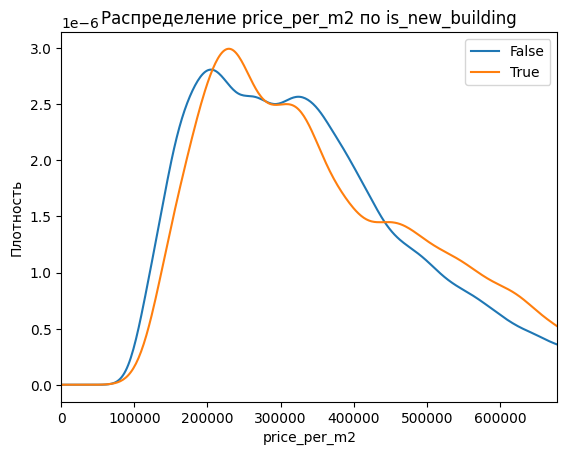

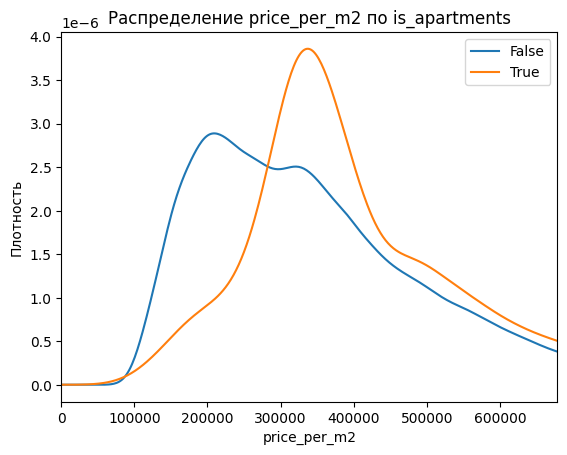

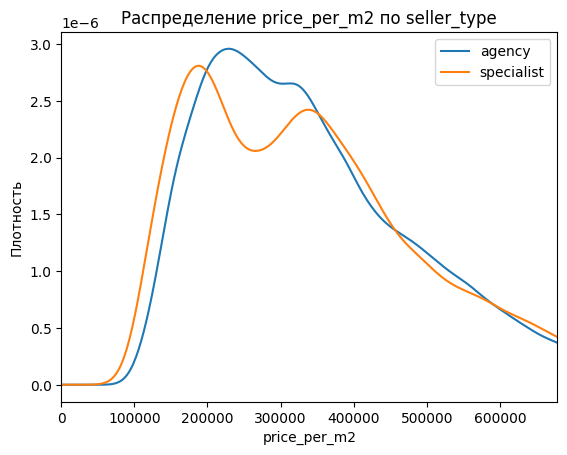

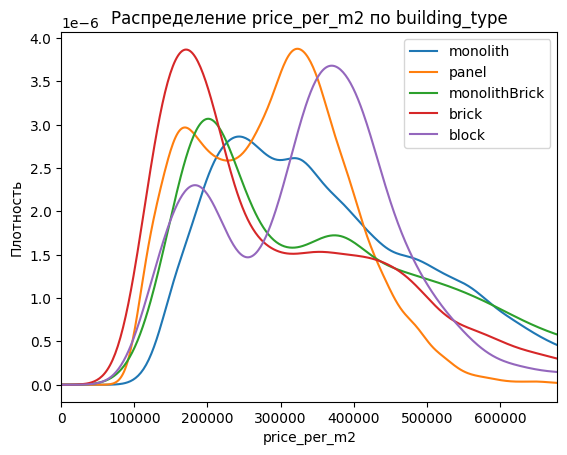

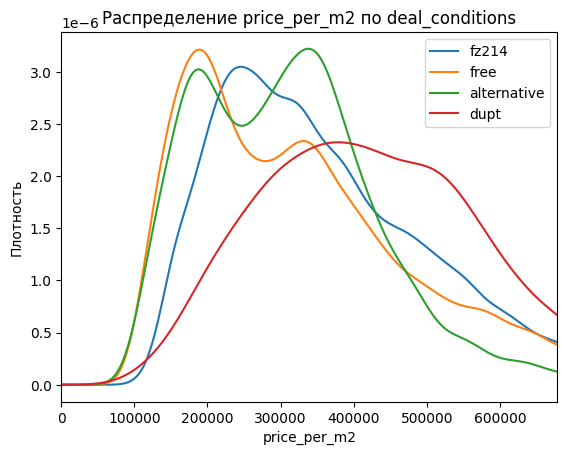

In [18]:
overlay_features = ['is_new_building', 'is_apartments', 'seller_type', 'building_type', 'deal_conditions']
clip = dt['price_per_m2'].quantile(0.95)

for col in overlay_features:
    counts = dt[dt[col].ne('unknown')][col].value_counts()
    cats = counts[counts >= 500].index
    plt.figure()
    for val in cats:
        dt.loc[dt[col] == val, 'price_per_m2'].plot(kind='kde', label=str(val))
    plt.title(f'Распределение price_per_m2 по {col}')
    plt.xlabel('price_per_m2')
    plt.ylabel('Плотность')
    plt.xlim(0, clip)
    plt.legend()
    plt.show()

Посмотрим, где должна находиться квартира, чтобы ее можно было дороже продать

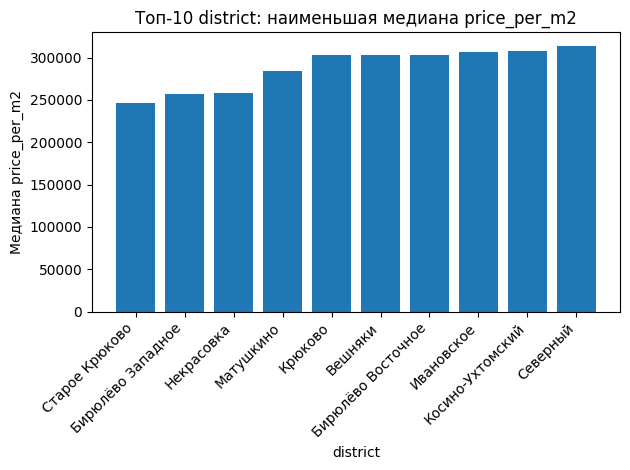

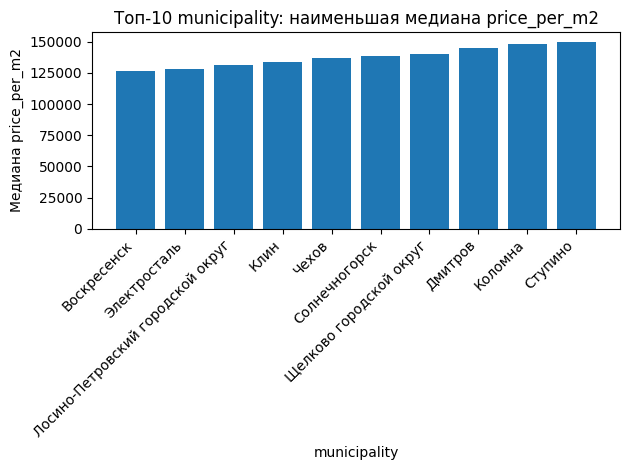

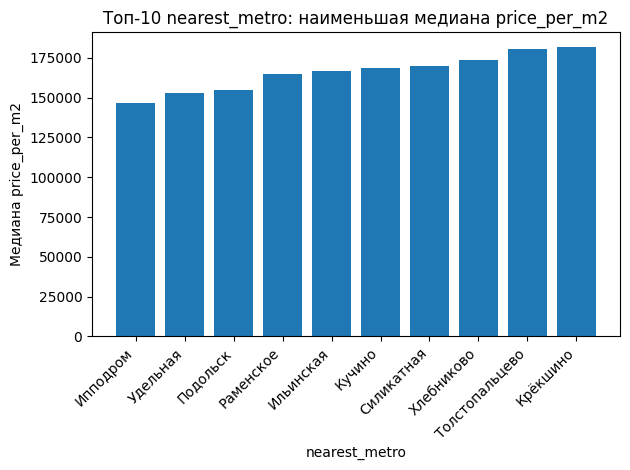

In [19]:
def lowest_median_bar(frame, col, target='price_per_m2', top=10, min_count=100):
    sub = frame[frame[col].ne('unknown')]
    stats = sub.groupby(col)[target].agg(['median', 'count'])
    stats = stats[stats['count'] >= min_count].sort_values('median').head(top)
    plt.figure()
    plt.bar(stats.index, stats['median'])
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Топ-{top} {col}: наименьшая медиана price_per_m2')
    plt.xlabel(col)
    plt.ylabel('Медиана price_per_m2')
    plt.tight_layout()
    plt.show()

for col in ['district', 'municipality', 'nearest_metro']:
    lowest_median_bar(dt, col)

### Анализ важности признаков

c:\Users\Никита\AppData\Local\Programs\Python\Python313\Lib\site-packages\phik\data_quality.py:82: UserWarning: Not enough unique value for variable event_closed for analysis 1. Dropping this column
  warnings.warn(


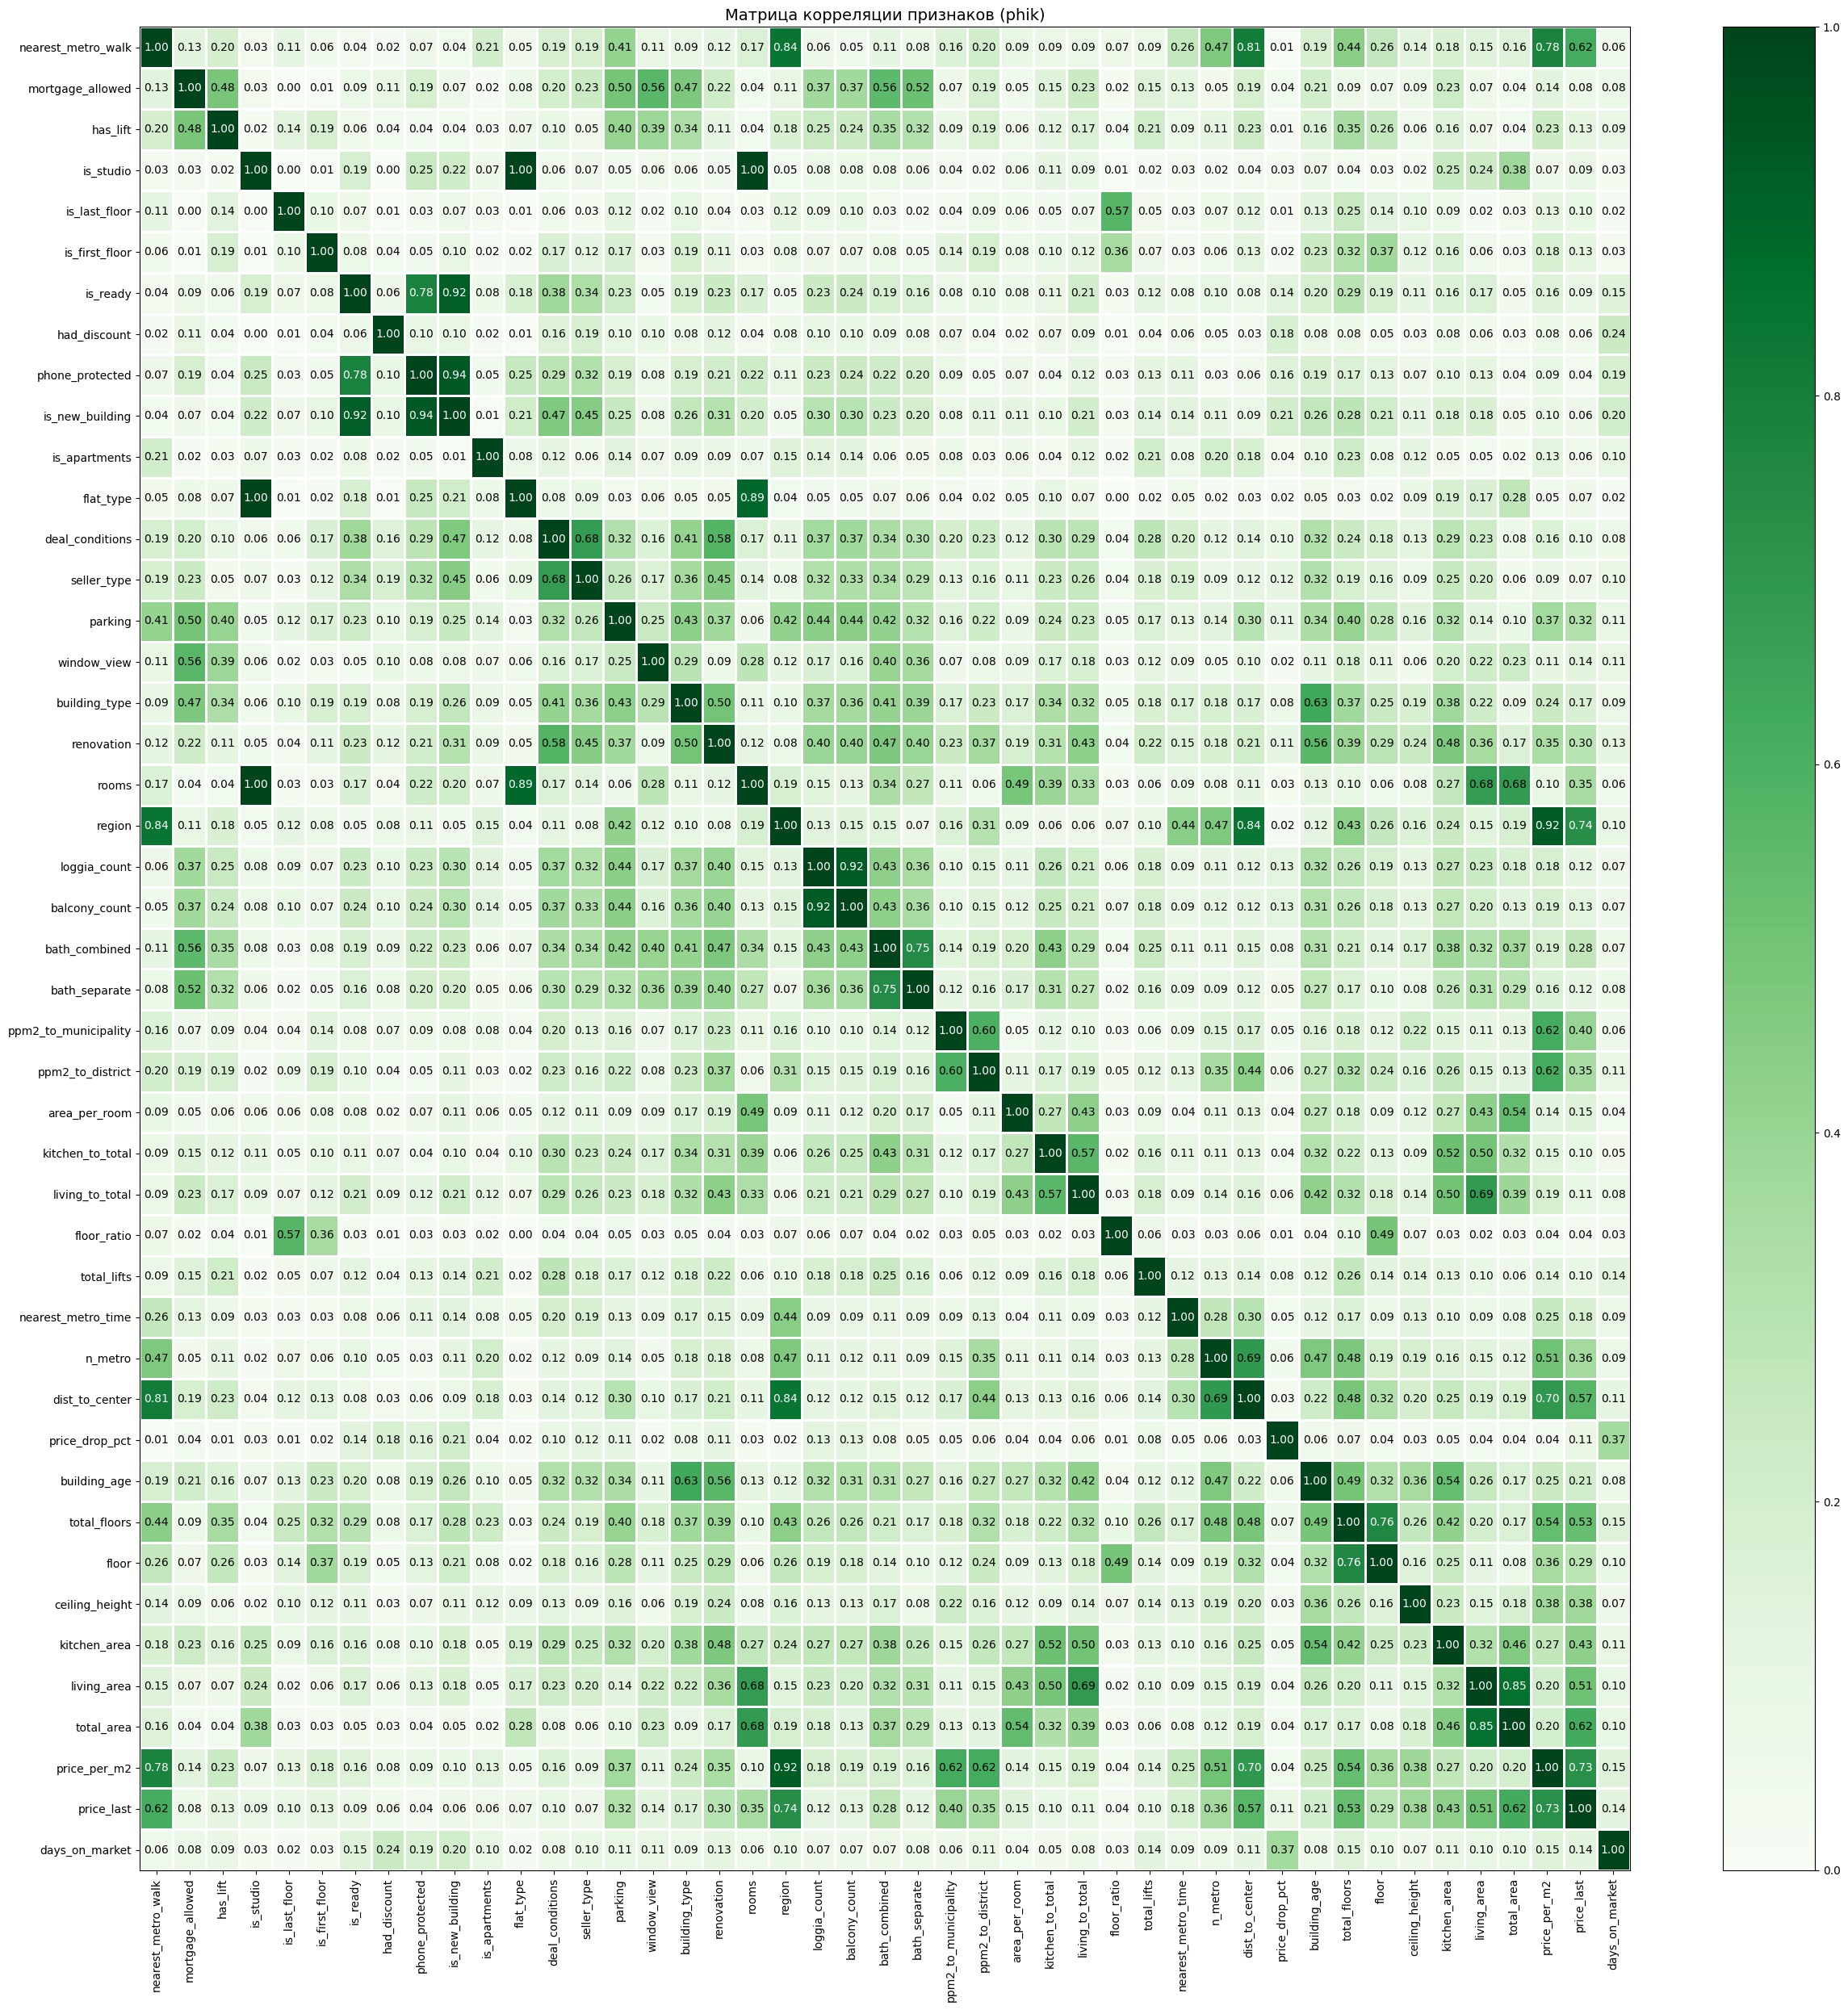

In [20]:
interval_cols = [
    'days_on_market', 'price_last', 'price_per_m2', 'total_area', 'living_area',
    'kitchen_area', 'ceiling_height', 'floor', 'total_floors', 'building_age',
    'price_drop_pct', 'dist_to_center', 'n_metro', 'nearest_metro_time', 'total_lifts',
    'floor_ratio', 'living_to_total', 'kitchen_to_total', 'area_per_room',
    'ppm2_to_district', 'ppm2_to_municipality',
    'bath_separate', 'bath_combined', 'balcony_count', 'loggia_count',
]
phik_cols = interval_cols + [
    'region', 'rooms', 'renovation', 'building_type', 'window_view',
    'parking', 'seller_type', 'deal_conditions', 'flat_type', 'is_apartments', 'is_new_building',
    'phone_protected', 'had_discount', 'is_ready', 'event_closed',
    'is_first_floor', 'is_last_floor', 'is_studio', 'has_lift', 'mortgage_allowed', 'nearest_metro_walk',
]

phik_df = dt[phik_cols].copy()
phik_df[interval_cols] = phik_df[interval_cols].astype('float64')
for col in phik_cols:
    if str(phik_df[col].dtype) in ('boolean', 'bool', 'Int64'):
        phik_df[col] = phik_df[col].astype('int64').astype('object')

phik_matrix = phik_df.phik_matrix(interval_cols=interval_cols)

plot_correlation_matrix(
    phik_matrix.values,
    x_labels=phik_matrix.columns,
    y_labels=phik_matrix.index,
    vmin=0, vmax=1, color_map='Greens',
    title='Матрица корреляции признаков (phik)',
    fontsize_factor=1,
    figsize=(25, 25)
)
plt.tight_layout()
plt.show()

### Бейзлайн и анализ важности признаков

In [21]:
leak_cols = ['days_on_market', 'first_seen', 'event_closed', 'price_points',
             'views_total', 'views_today', 'photos_count', 'had_discount', 'price_drop_pct']

y = dt['days_on_market'].astype(float)
X = dt.drop(columns=[c for c in leak_cols if c in dt.columns])

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
for c in cat_cols:
    X[c] = X[c].astype('category')

X.shape, len(cat_cols)

C:\Users\Nikita\AppData\Local\Temp\ipykernel_11556\1797300849.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


((140775, 52), 11)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=93,
    subsample=1,
    colsample_bytree=1,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train, categorical_feature=cat_cols)

pred = model.predict(X_test)
r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
print('R2:', round(r2, 4))
print('MAE (дней):', round(mae, 1))

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.029270 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5117
[LightGBM] [Info] Number of data points in the train set: 112620, number of used features: 52
[LightGBM] [Info] Start training from score 73.409288
R2: 0.4593
MAE (дней): 41.3


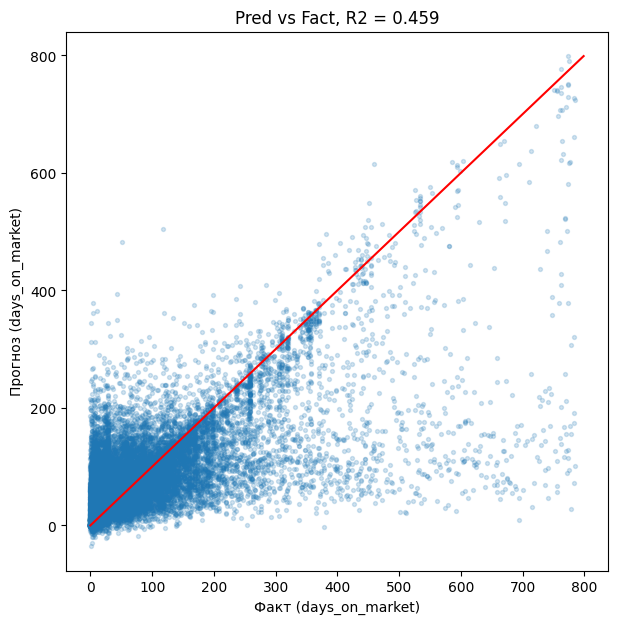

In [23]:
lim = max(y_test.max(), pred.max())

plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred, alpha=0.2, s=8)
plt.plot([0, lim], [0, lim], color='red')
plt.xlabel('Факт (days_on_market)')
plt.ylabel('Прогноз (days_on_market)')
plt.title(f'Pred vs Fact, R2 = {round(r2, 3)}')
plt.show()

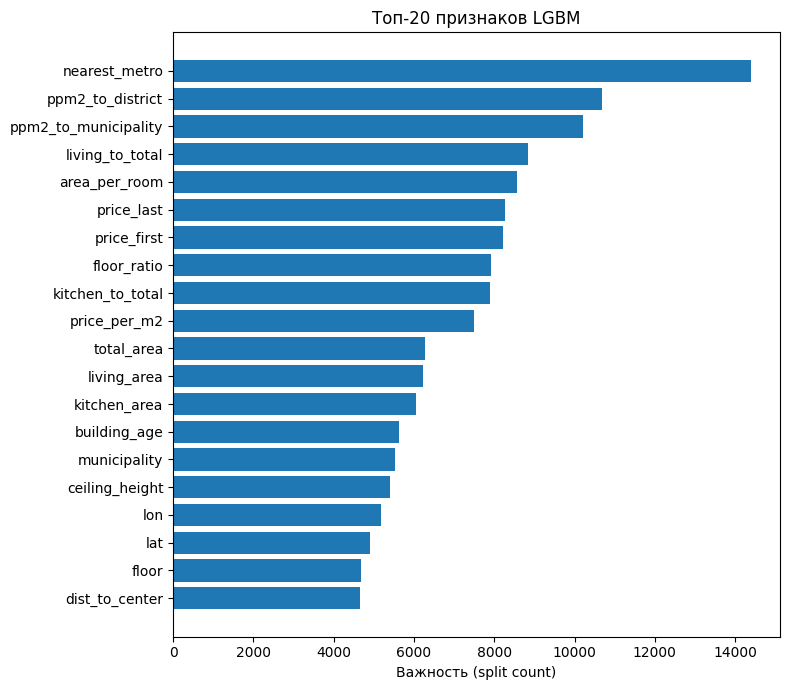

In [24]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values().tail(20)

plt.figure(figsize=(8, 7))
plt.barh(importance.index, importance.values)
plt.xlabel('Важность (split count)')
plt.title('Топ-20 признаков LGBM')
plt.tight_layout()
plt.show()

### Финальный экспорт датасета

In [25]:
final = dt.copy()
bool_cols = final.select_dtypes(include='bool').columns
final[bool_cols] = final[bool_cols].astype('int8')
final.to_csv('./data/data_final.csv', index=False)
final.shape

(140775, 59)